In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

!pip -q install nnunetv2 nibabel medpy SimpleITK


Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 kB 16.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.3/156.3 kB 16.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 7.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 50.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.7/26.7 MB 102.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 112.

In [ ]:
import os, subprocess
RESULTS_DIR = "/content/drive/MyDrive/Brain_segmentation"  # contains Dataset002_BRATS19/...
SRC = "/content/drive/MyDrive/Brain_segmentation/Sample_data/BaTS_2021/BraTS2021_00495"

os.environ["nnUNet_results"] = RESULTS_DIR
print("nnUNet_results =", os.environ["nnUNet_results"])
subprocess.run(["ls","-la",RESULTS_DIR])
subprocess.run(["ls","-la",SRC])


nnUNet_results = /content/drive/MyDrive/Brain_segmentation


CompletedProcess(args=['ls', '-la', '/content/drive/MyDrive/Brain_segmentation/Sample_data/BaTS_2021/BraTS2021_00495'], returncode=0)

In [ ]:
from pathlib import Path
import nibabel as nib

src = Path(SRC)
IM_IN = Path("/content/imagesTs"); IM_IN.mkdir(parents=True, exist_ok=True)
GT    = Path("/content/labelsTs"); GT.mkdir(parents=True, exist_ok=True)

case = "BraTS2021_00495"  # matches your filenames

# source files (your exact names)
t1    = src/f"{case}_t1.nii"
t1ce  = src/f"{case}_t1ce.nii"
t2    = src/f"{case}_t2.nii"
flair = src/f"{case}_flair.nii"
seg   = src/f"{case}_seg.nii"

# write with correct channel mapping: 0=t1, 1=t1ce, 2=t2, 3=flair
nib.save(nib.load(str(t1)),    str(IM_IN/f"{case}_0000.nii.gz"))
nib.save(nib.load(str(t1ce)),  str(IM_IN/f"{case}_0001.nii.gz"))
nib.save(nib.load(str(t2)),    str(IM_IN/f"{case}_0002.nii.gz"))
nib.save(nib.load(str(flair)), str(IM_IN/f"{case}_0003.nii.gz"))
nib.save(nib.load(str(seg)),   str(GT/f"{case}.nii.gz"))

sorted([p.name for p in IM_IN.glob("*.nii.gz")])


['BraTS2021_00495_0000.nii.gz',
 'BraTS2021_00495_0001.nii.gz',
 'BraTS2021_00495_0002.nii.gz',
 'BraTS2021_00495_0003.nii.gz']

In [ ]:
!nnUNetv2_predict \
  -i /content/imagesTs \
  -o /content/preds \
  -d Dataset002_BRATS19 \
  -c 3d_fullres \
  -tr nnUNetTrainer \
  -p nnUNetPlans \
  -f 0
# later for best accuracy: use "-f 0 1 2 3 4" (ensemble) and keep TTA ON (do NOT add --disable_tta)


nnUNet_raw is not defined and nnU-Net can only be used on data for which preprocessed files are already present on your system. nnU-Net cannot be used for experiment planning and preprocessing like this. If this is not intended, please read documentation/setting_up_paths.md for information on how to set this up properly.
nnUNet_preprocessed is not defined and nnU-Net can not be used for preprocessing or training. If this is not intended, please read documentation/setting_up_paths.md for information on how to set this up.

#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################

/usr/local/lib/python3.12/dist-packages/nnunetv2/utilities/plans_handl

In [ ]:
import numpy as np, nibabel as nib
from medpy.metric.binary import dc

pred = nib.load(f"/content/preds/{case}.nii.gz").get_fdata().astype(np.int16)
gt   = nib.load(f"/content/labelsTs/{case}.nii.gz").get_fdata().astype(np.int16)

print("Unique pred labels:", np.unique(pred))
print("Whole-tumor Dice:", float(dc(pred>0, gt>0)))  # binary tumor vs tumor

# BraTS classes: 1=edema, 2=nonenh/necrotic, 4=enhancing
per = {l: (float(dc(pred==l, gt==l)) if (gt==l).any() or (pred==l).any() else np.nan) for l in [1,2,4]}
print("Per-class Dice:", per)


Unique pred labels: [0 1 2 4]
Whole-tumor Dice: 0.9658663936524188
Per-class Dice: {1: 0.9743365625075874, 2: 0.9152486040946557, 4: 0.9477143617271006}


In [ ]:
import numpy as np, nibabel as nib
from medpy.metric.binary import dc

pred = nib.load(f"/content/preds/{case}.nii.gz").get_fdata().astype(np.int16)
gt   = nib.load(f"/content/labelsTs/{case}.nii.gz").get_fdata().astype(np.int16)

print("Unique pred labels:", np.unique(pred))
print("Whole-tumor Dice:", float(dc(pred>0, gt>0)))  # binary tumor vs tumor

# BraTS classes: 1=edema, 2=nonenh/necrotic, 4=enhancing
per = {l: (float(dc(pred==l, gt==l)) if (gt==l).any() or (pred==l).any() else np.nan) for l in [1,2,4]}
print("Per-class Dice:", per)


Unique pred labels: [0 1 2 4]
Whole-tumor Dice: 0.9658663936524188
Per-class Dice: {1: 0.9743365625075874, 2: 0.9152486040946557, 4: 0.9477143617271006}


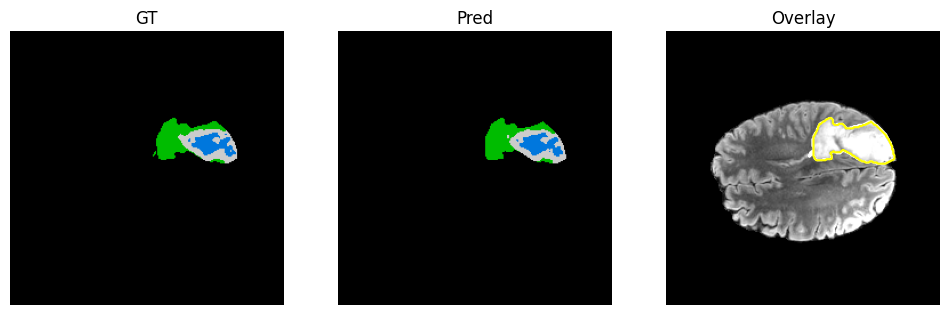

In [ ]:
import matplotlib.pyplot as plt
mri = nib.load(f"/content/imagesTs/{case}_0003.nii.gz").get_fdata()  # FLAIR background
z = int(np.median(np.where((pred>0)|(gt>0))[2])) if ((pred>0)|(gt>0)).any() else pred.shape[2]//2
p1,p99 = np.percentile(mri,[1,99]); bg = np.clip((mri-p1)/max(p99-p1,1e-6),0,1)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.title("GT");   plt.imshow(gt[:,:,z], cmap='nipy_spectral'); plt.axis('off')
plt.subplot(1,3,2); plt.title("Pred"); plt.imshow(pred[:,:,z], cmap='nipy_spectral'); plt.axis('off')
plt.subplot(1,3,3); plt.title("Overlay"); plt.imshow(bg[:,:,z], cmap='gray')
plt.contour(gt[:,:,z]>0, colors='white'); plt.contour(pred[:,:,z]>0, colors='yellow')
plt.axis('off'); plt.show()
